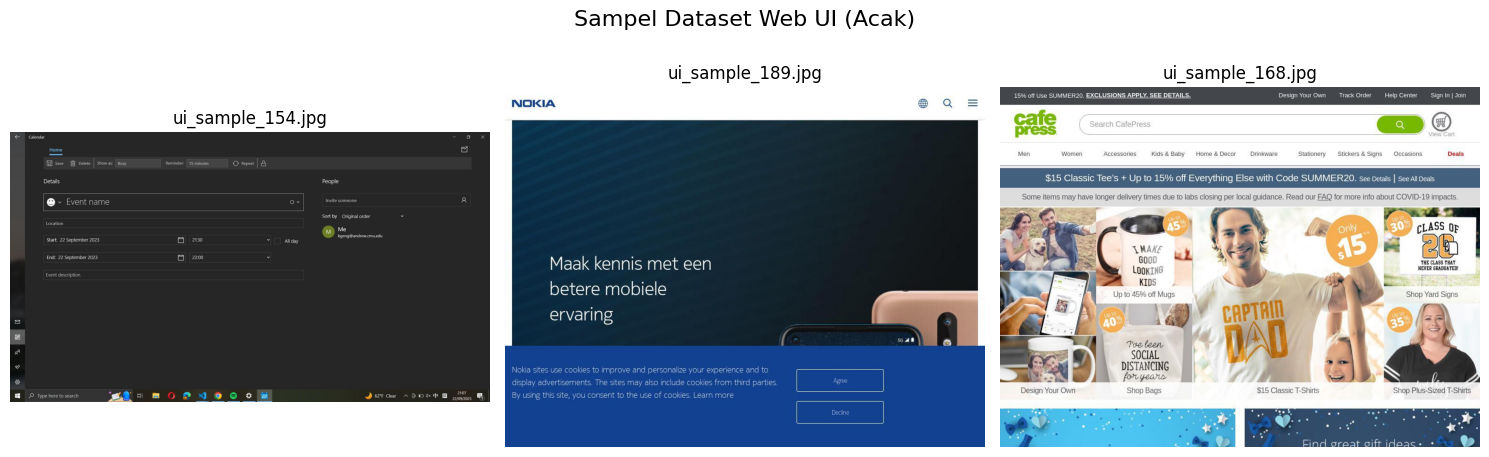

In [109]:
import os
import random  # <-- Tambahan baru
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Menampilkan 3 Sampel Gambar Desain UI secara ACAK
raw_folder = 'data/raw'

# Ambil semua daftar file berakhiran .jpg
all_images = [f for f in os.listdir(raw_folder) if f.endswith('.jpg')]

# Pilih 3 gambar secara acak dari total daftar file
image_files = random.sample(all_images, 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img_file in zip(axes, image_files):
    img_path = os.path.join(raw_folder, img_file)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_file)
    ax.axis('off')
    
plt.suptitle("Sampel Dataset Web UI (Acak)", fontsize=16)
plt.tight_layout()
plt.show()

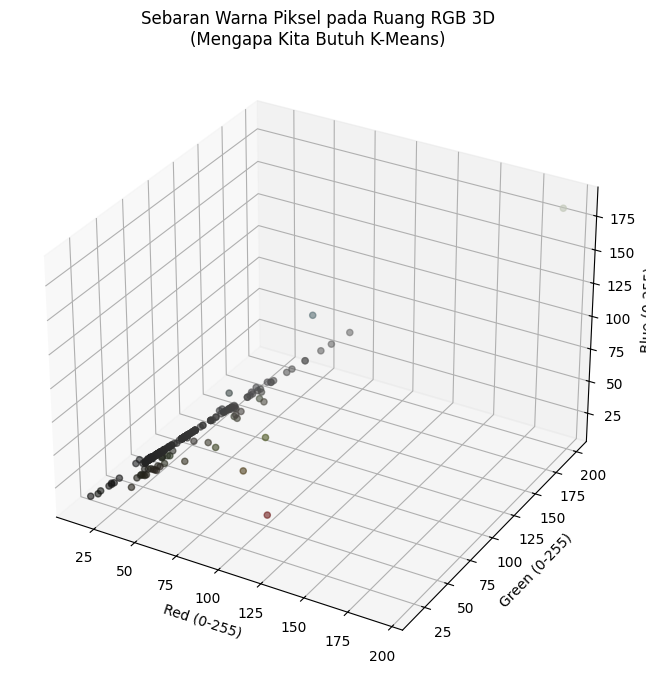

In [110]:
# 2. Membedah Distribusi Warna (RGB 3D Scatter Plot)
# Kita ambil gambar pertama sebagai kelinci percobaan
sample_img_path = os.path.join(raw_folder, image_files[0])

# Perkecil gambar agar laptop tidak nge-lag saat memproses jutaan piksel
img = Image.open(sample_img_path).resize((100, 100))
img_array = np.array(img)

# Ubah matriks gambar (100x100x3) menjadi daftar piksel (10000x3)
pixels = img_array.reshape(-1, 3)

# Kita ambil 1000 piksel acak untuk diplot di ruang 3D
np.random.shuffle(pixels)
sample_pixels = pixels[:1000]

r = sample_pixels[:, 0]
g = sample_pixels[:, 1]
b = sample_pixels[:, 2]

# Normalisasi warna RGB (0-255) menjadi (0-1) untuk format warna matplotlib
colors = sample_pixels / 255.0

# Membuat plot 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot titik-titik warna
ax.scatter(r, g, b, c=colors, marker='o', s=20, alpha=0.6)

ax.set_xlabel('Red (0-255)')
ax.set_ylabel('Green (0-255)')
ax.set_zlabel('Blue (0-255)')
ax.set_title('Sebaran Warna Piksel pada Ruang RGB 3D\n(Mengapa Kita Butuh K-Means)')

plt.show()

Memulai proses K-Means Clustering (Mencari 5 warna dominan)...


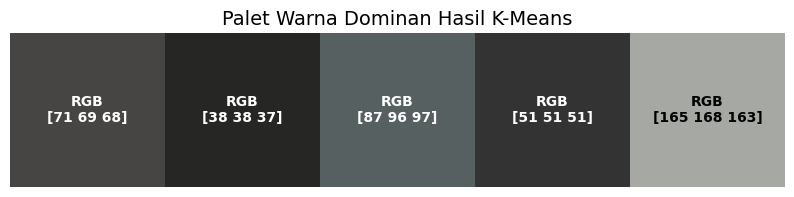

In [111]:
from sklearn.cluster import KMeans
import matplotlib.patches as patches

# 1. Siapkan data piksel dari gambar sampel tadi
# Kita batasi jumlah piksel yang diproses agar komputasi K-Means lebih cepat
pixels_subset = pixels[np.random.choice(pixels.shape[0], 5000, replace=False)]

print("Memulai proses K-Means Clustering (Mencari 5 warna dominan)...")
# 2. Inisialisasi dan jalankan algoritma K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(pixels_subset)

# 3. Ambil titik tengah (centroid) sebagai warna dominan
dominant_colors = kmeans.cluster_centers_.astype(int)

# 4. Visualisasikan Palet Warna
fig, ax = plt.subplots(figsize=(10, 2))
for i, color in enumerate(dominant_colors):
    # Buat kotak warna untuk setiap warna dominan
    rect = patches.Rectangle((i, 0), 1, 1, facecolor=color/255.0)
    ax.add_patch(rect)
    
    # Tulis kode RGB di atas warna tersebut
    plt.text(i + 0.5, 0.5, f"RGB\n{color}", ha='center', va='center', 
             color='white' if np.mean(color) < 128 else 'black', fontweight='bold')

ax.set_xlim(0, len(dominant_colors))
ax.set_ylim(0, 1)
ax.axis('off')
plt.title("Palet Warna Dominan Hasil K-Means", fontsize=14)
plt.show()

In [112]:
# Fungsi untuk menghitung Luminance Relatif sesuai standar WCAG 2.1
def get_luminance(rgb):
    r, g, b = [x / 255.0 for x in rgb]
    r = r / 12.92 if r <= 0.03928 else ((r + 0.055) / 1.055) ** 2.4
    g = g / 12.92 if g <= 0.03928 else ((g + 0.055) / 1.055) ** 2.4
    b = b / 12.92 if b <= 0.03928 else ((b + 0.055) / 1.055) ** 2.4
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

# Fungsi untuk menghitung Rasio Kontras
def get_contrast_ratio(color1, color2):
    lum1 = get_luminance(color1)
    lum2 = get_luminance(color2)
    lighter = max(lum1, lum2)
    darker = min(lum1, lum2)
    return (lighter + 0.05) / (darker + 0.05)

print("--- Hasil Uji Kontras WCAG 2.1 (Standar Minimal 4.5:1) ---\n")

# Mari kita uji setiap kombinasi warna dari palet yang dihasilkan K-Means
for i in range(len(dominant_colors)):
    for j in range(i + 1, len(dominant_colors)):
        c1, c2 = dominant_colors[i], dominant_colors[j]
        ratio = get_contrast_ratio(c1, c2)
        
        status = "✅ LULUS" if ratio >= 4.5 else "❌ GAGAL"
        print(f"Kombinasi Warna {i+1} & {j+1}: Rasio {ratio:.2f}:1 -> {status}")

--- Hasil Uji Kontras WCAG 2.1 (Standar Minimal 4.5:1) ---

Kombinasi Warna 1 & 2: Rasio 1.59:1 -> ❌ GAGAL
Kombinasi Warna 1 & 3: Rasio 1.48:1 -> ❌ GAGAL
Kombinasi Warna 1 & 4: Rasio 1.33:1 -> ❌ GAGAL
Kombinasi Warna 1 & 5: Rasio 3.96:1 -> ❌ GAGAL
Kombinasi Warna 2 & 3: Rasio 2.34:1 -> ❌ GAGAL
Kombinasi Warna 2 & 4: Rasio 1.20:1 -> ❌ GAGAL
Kombinasi Warna 2 & 5: Rasio 6.30:1 -> ✅ LULUS
Kombinasi Warna 3 & 4: Rasio 1.96:1 -> ❌ GAGAL
Kombinasi Warna 3 & 5: Rasio 2.69:1 -> ❌ GAGAL
Kombinasi Warna 4 & 5: Rasio 5.25:1 -> ✅ LULUS


C:\Users\affan\AppData\Local\Temp\ipykernel_16904\3909092455.py:52: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\affan\AppData\Local\Temp\ipykernel_16904\3909092455.py:52: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\#Kuliah\SMT 6\PDM\project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\#Kuliah\SMT 6\PDM\project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


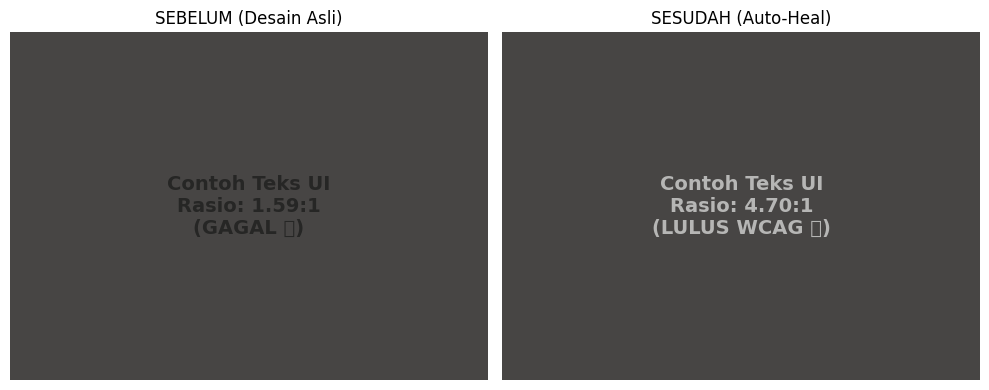

In [113]:
# --- MARI KITA UJI COBA SIMULASINYA (VERSI CERDAS) ---

warna_background = None
warna_foreground = None
rasio_asli = 0

# 1. Cari secara spesifik kombinasi warna yang GAGAL (< 4.5) untuk di-heal
for i in range(len(dominant_colors)):
    for j in range(i + 1, len(dominant_colors)):
        c1, c2 = dominant_colors[i], dominant_colors[j]
        ratio = get_contrast_ratio(c1, c2)
        
        if ratio < 4.5:
            warna_background = c1
            warna_foreground = c2
            rasio_asli = ratio
            break # Berhenti mencari jika sudah menemukan yang gagal
    if warna_background is not None:
        break

# Jika secara ajaib semua warna di desain itu lulus WCAG alami:
if warna_background is None:
    print("Wah! Semua kombinasi palet dari gambar ini sudah lulus WCAG secara alami.")
    warna_background, warna_foreground = dominant_colors[0], dominant_colors[1]
    rasio_asli = get_contrast_ratio(warna_background, warna_foreground)

# 2. Jalankan mesin penyembuh!
healed_color, rasio_baru = auto_heal_contrast(warna_background, warna_foreground)

# 3. Label Dinamis
status_asli = "LULUS ✅" if rasio_asli >= 4.5 else "GAGAL ❌"

# 4. Visualisasikan Hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Kotak Sebelum
rect1 = patches.Rectangle((0, 0), 1, 1, facecolor=warna_background/255.0)
axes[0].add_patch(rect1)
axes[0].text(0.5, 0.5, f"Contoh Teks UI\nRasio: {rasio_asli:.2f}:1\n({status_asli})", 
             ha='center', va='center', fontsize=14, fontweight='bold', color=warna_foreground/255.0)
axes[0].axis('off')
axes[0].set_title("SEBELUM (Desain Asli)")

# Kotak Sesudah (Auto-Heal)
rect2 = patches.Rectangle((0, 0), 1, 1, facecolor=warna_background/255.0)
axes[1].add_patch(rect2)
axes[1].text(0.5, 0.5, f"Contoh Teks UI\nRasio: {rasio_baru:.2f}:1\n(LULUS WCAG ✅)", 
             ha='center', va='center', fontsize=14, fontweight='bold', color=np.array(healed_color)/255.0)
axes[1].axis('off')
axes[1].set_title("SESUDAH (Auto-Heal)")

plt.tight_layout()
plt.show()